In [2]:
# auto-reload edited modules without restarting kernel
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

# default figure size: (10, 4); for larger plots use (12, 4)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 100

SEED = 42
np.random.seed(SEED)

# 1. Data Loading

## 1.1 Fetch stock data

In [3]:
from src.data import TICKER_DEFAULT, fetch_stock

stocks = {TICKER_DEFAULT: fetch_stock(TICKER_DEFAULT)}
print(TICKER_DEFAULT, stocks[TICKER_DEFAULT].shape,
      "from", stocks[TICKER_DEFAULT].index.min().date(),
      "to",   stocks[TICKER_DEFAULT].index.max().date())

MSFT (3615, 6) from 2012-01-03 to 2026-05-19


In [4]:
from src.data import fetch_macro

macro = fetch_macro()
print("Macro shape:", macro.shape)
print(macro.tail())

Macro shape: (3620, 6)
                  VIX          SPX        DXY    TNX         OIL         GOLD
Date                                                                         
2026-05-14  17.260000  7501.240234  98.879997  4.461  101.169998  4678.100098
2026-05-15  18.430000  7408.500000  99.269997  4.595  105.419998  4555.799805
2026-05-18  17.820000  7403.049805  98.970001  4.623  108.660004  4552.500000
2026-05-19  18.059999  7353.609863  99.300003  4.667  107.769997  4506.299805
2026-05-20  17.930000  7353.609863  99.347000  4.643  101.209999  4506.399902


In [5]:
from src.data import build_dataset

dataset = build_dataset(TICKER_DEFAULT, stocks, macro)
print("Dataset shape:", dataset.shape)
print("Columns:", list(dataset.columns))
dataset.head()

Dataset shape: (3615, 12)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Ticker', 'VIX', 'SPX', 'DXY', 'TNX', 'OIL', 'GOLD']


,Open,High,Low,Close,Volume,Ticker,VIX,SPX,DXY,TNX,OIL,GOLD
Date,,,,,,,,,,,,
2012-01-03,20.745786,21.066154,20.620765,20.917692,64731500,MSFT,22.969999,1277.060059,79.610001,1.960,102.959999,1599.699951
2012-01-04,20.956760,21.464660,20.925505,21.409964,80516100,MSFT,22.219999,1277.300049,80.089996,1.995,103.220001,1611.900024
2012-01-05,21.394333,21.667819,21.324010,21.628750,56081400,MSFT,21.480000,1281.060059,80.940002,1.993,101.809998,1619.400024
2012-01-06,21.511549,22.027263,21.511549,21.964752,99455500,MSFT,20.629999,1277.810059,81.239998,1.961,101.559998,1616.099976
2012-01-09,21.917871,21.956941,21.660014,21.675642,59706800,MSFT,21.070000,1280.699951,81.050003,1.960,101.309998,1607.500000


# 2. EDA & Pre-processing

## 2.1 Dataset Overview

In [6]:
df = dataset.copy()
df["LogVolume"] = np.log1p(df["Volume"]) # Volume is heavy right-tail

print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nDate range:", df.index.min().date(), "->", df.index.max().date())

Shape: (3615, 13)

Dtypes:
Open         float64
High         float64
Low          float64
Close        float64
Volume         int64
Ticker           str
VIX          float64
SPX          float64
DXY          float64
TNX          float64
OIL          float64
GOLD         float64
LogVolume    float64
dtype: object

Date range: 2012-01-03 -> 2026-05-19


## 2.2 Missing Values

In [7]:
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing": missing_count, "pct(%)": missing_pct})
print(missing_table)

df = df.dropna()
print("After dropna:", df.shape)

           missing  pct(%)
Open             0     0.0
High             0     0.0
Low              0     0.0
Close            0     0.0
Volume           0     0.0
Ticker           0     0.0
VIX              0     0.0
SPX              0     0.0
DXY              0     0.0
TNX              0     0.0
OIL              0     0.0
GOLD             0     0.0
LogVolume        0     0.0
After dropna: (3615, 13)


## 2.3 Duplicates

In [8]:
print("Duplicated rows:",  df.duplicated().sum())
print("Duplicated index:", df.index.duplicated().sum())

df = df[~df.index.duplicated(keep="first")]

Duplicated rows: 0
Duplicated index: 0


## 2.4 Outliers (IQR rule, k=1.5)

Close       :    0 outliers (0.0%)  bounds=[-325.38, 650.89]
Volume      :  179 outliers (5.0%)  bounds=[-1882400.00, 60030000.00]
LogVolume   :   60 outliers (1.7%)  bounds=[16.06, 18.24]


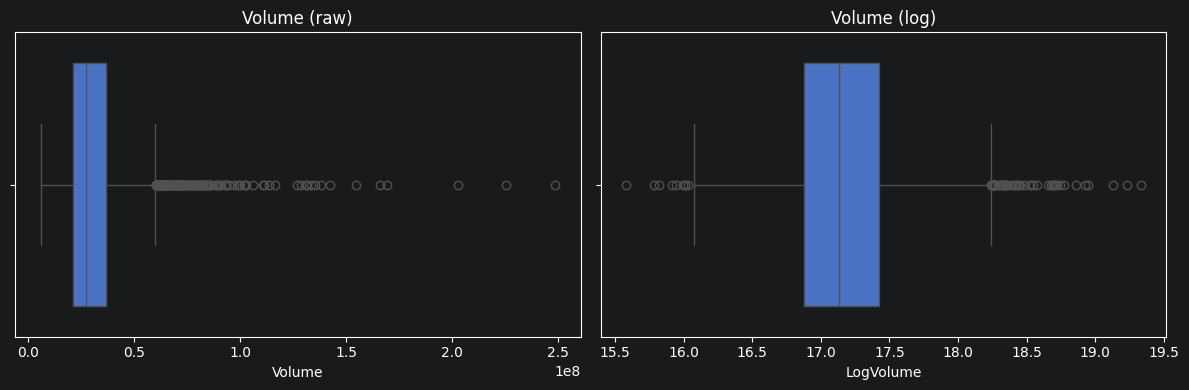

In [9]:
def iqr_outliers(series: pd.Series, k: float = 1.5):
    """Outlier if outside [Q1 - k*IQR, Q3 + k*IQR]."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - k * IQR, Q3 + k * IQR
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

for col in ["Close", "Volume", "LogVolume"]:
    mask, lo, hi = iqr_outliers(df[col])
    print(f"{col:12s}: {mask.sum():4d} outliers ({mask.mean()*100:.1f}%)  "
          f"bounds=[{lo:.2f}, {hi:.2f}]")

# boxplot before/after log on Volume
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["Volume"],     ax=axes[0]); axes[0].set_title("Volume (raw)")
sns.boxplot(x=df["LogVolume"],  ax=axes[1]); axes[1].set_title("Volume (log)")
plt.tight_layout()
plt.show()

## 2.5 Uniqueness check

In [10]:
print(df.nunique().sort_values())

Ticker          1
VIX          1581
DXY          1834
TNX          2134
OIL          2875
GOLD         2984
Close        3478
Volume       3602
LogVolume    3602
SPX          3602
High         3608
Open         3611
Low          3613
dtype: int64


## 2.6 Descriptive Statistics

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
desc = df[numeric_cols].describe().T
desc["median"] = df[numeric_cols].median()
desc = desc[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]]
desc.round(2)

,count,mean,median,std,min,25%,50%,75%,max
Open,3615.0,174.21,107.17,149.56,20.75,40.68,107.17,284.64,5.520200e+02
High,3615.0,175.83,107.81,150.85,21.07,41.02,107.81,286.47,5.522400e+02
Low,3615.0,172.50,106.67,148.14,20.62,40.35,106.67,281.66,5.385300e+02
Close,3615.0,174.24,107.34,149.54,20.92,40.72,107.34,284.79,5.398300e+02
Volume,3615.0,31596465.17,27484200.00,16578095.00,5855900.00,21334750.00,27484200.00,36812850.00,2.484285e+08
VIX,3615.0,17.76,16.16,6.52,9.14,13.49,16.16,20.09,8.269000e+01
SPX,3615.0,3292.33,2832.94,1532.36,1277.06,2059.78,2832.94,4320.44,7.501240e+03
DXY,3615.0,94.82,96.45,8.11,78.27,90.94,96.45,99.88,1.141100e+02
TNX,3615.0,2.60,2.39,1.06,0.50,1.80,2.39,3.43,4.990000e+00
OIL,3615.0,69.61,68.15,20.97,-37.63,52.78,68.15,86.60,1.237000e+02


## 2.7 Univariate, Bivariate, Multivariate analysis

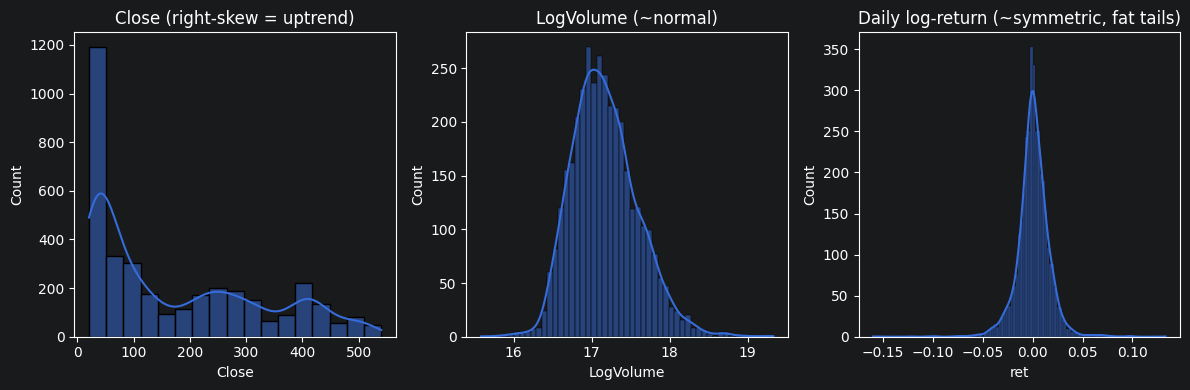

In [12]:
# temporary log-return for analysis (re-defined properly in features.py)
df["ret"] = np.log(df["Close"] / df["Close"].shift(1))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sns.histplot(df["Close"],     kde=True, ax=axes[0]); axes[0].set_title("Close (right-skew = uptrend)")
sns.histplot(df["LogVolume"], kde=True, ax=axes[1]); axes[1].set_title("LogVolume (~normal)")
sns.histplot(df["ret"].dropna(), kde=True, ax=axes[2]); axes[2].set_title("Daily log-return (~symmetric, fat tails)")
plt.tight_layout(); plt.show()

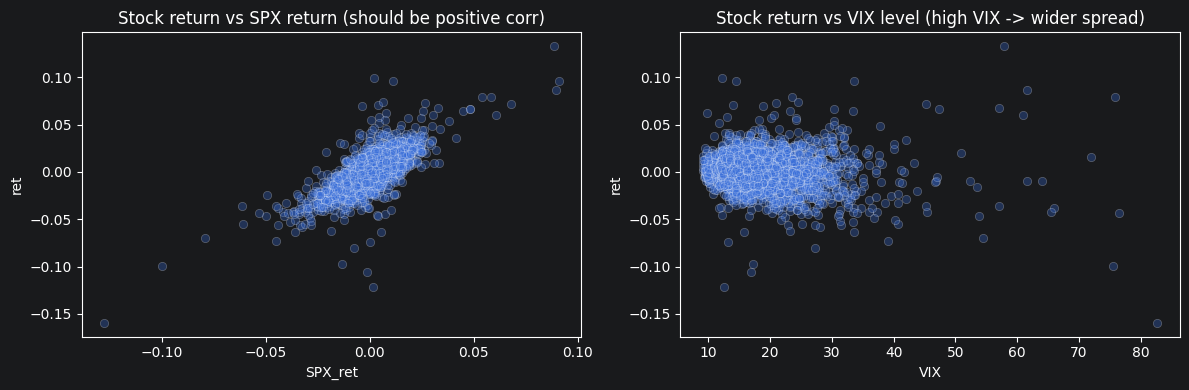

In [13]:
df["SPX_ret"] = np.log(df["SPX"] / df["SPX"].shift(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=df["SPX_ret"], y=df["ret"], ax=axes[0], alpha=0.3)
axes[0].set_title("Stock return vs SPX return (should be positive corr)")
sns.scatterplot(x=df["VIX"], y=df["ret"], ax=axes[1], alpha=0.3)
axes[1].set_title("Stock return vs VIX level (high VIX -> wider spread)")
plt.tight_layout(); plt.show()

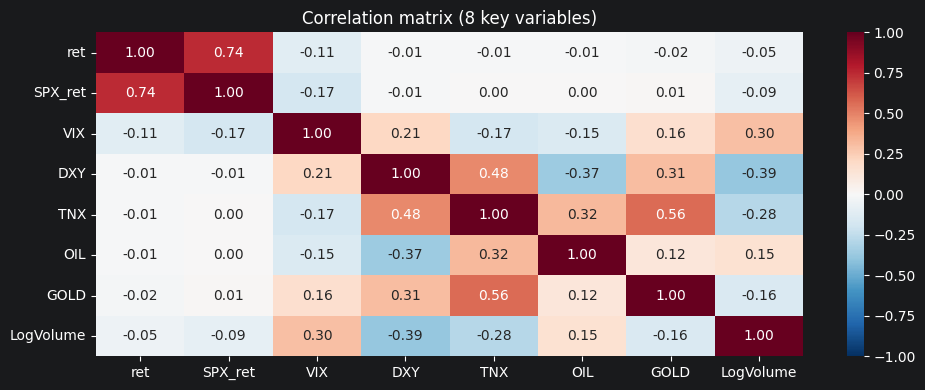

In [14]:
corr_cols = ["ret", "SPX_ret", "VIX", "DXY", "TNX", "OIL", "GOLD", "LogVolume"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix (8 key variables)")
plt.tight_layout(); plt.show()

## 2.8 Conclusion & Strategy

**Findings**:
1. Data is clean no missing after merge, no duplicates.
2. Close shows uptrend (non-stationary) → MUST predict returns, not prices.
3. Volume is right-skewed → use log(1+Volume) everywhere.
4. Daily returns are ~symmetric but have fat tails → robust to outliers, winsorize target at 3ơ.
5. SPX/VIX correlate strongly with stock return → keep all 6 macros as features.

**Decisions for next phase**:
- Target = log-return at horizon h=5 (1 trading week).
- Features = technical (lag, MA, RSI, MACD, Bollinger, microstructure)
  + macro (VIX/SPX/DXY/TNX/OIL/GOLD)
  + calendar (day-of-week, month).
- Split 70/15/15 time-aware, no shuffle.
- Models: NaiveZero + AlwaysLong baselines + LinearRegression + RandomForest.
- Hyperparameter tune RF on held-out val set.
- Evaluate by IC + DirAcc + walk-forward Sharpe.

# 3. Feature Engineering

In [15]:
from src.features import build_training_set

feat_df = build_training_set(TICKER_DEFAULT, stocks, macro)
print("Feature df shape:", feat_df.shape)
print("Columns:", list(feat_df.columns))

Feature df shape: (3547, 60)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Ticker', 'VIX', 'SPX', 'DXY', 'TNX', 'OIL', 'GOLD', 'LogVolume', 'ret', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'ret_lag10', 'ret_ma5', 'ret_std5', 'ret_ma10', 'ret_std10', 'ret_ma20', 'ret_std20', 'price_ma20_ratio', 'price_ma50_ratio', 'gap', 'intraday_range', 'close_loc', 'bb_pos', 'rsi14', 'macd', 'macd_signal', 'macd_hist', 'vol_z20', 'VIX_ret1', 'VIX_ret5', 'VIX_lag1', 'SPX_ret1', 'SPX_ret5', 'SPX_lag1', 'DXY_ret1', 'DXY_ret5', 'DXY_lag1', 'TNX_ret1', 'TNX_ret5', 'TNX_lag1', 'OIL_ret1', 'OIL_ret5', 'OIL_lag1', 'GOLD_ret1', 'GOLD_ret5', 'GOLD_lag1', 'VIX_log_lag1', 'vix_z', 'dow', 'month', 'is_month_end', 'target']


# 4. Time-aware Split & Scaling

In [16]:
from src.data     import split_xy, time_split
from src.features import fit_winsorize

X, y, feature_cols = split_xy(feat_df)
X_train, y_train, X_val, y_val, X_test, y_test = time_split(X, y)
print(f"train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}")

# winsorize target
mean_, std_, lo_, hi_ = fit_winsorize(y_train, n_std=3.0)
y_train = y_train.clip(lo_, hi_)
y_val   = y_val.clip(lo_, hi_)
y_test  = y_test.clip(lo_, hi_)
print(f"target clipped to [{lo_:.4f}, {hi_:.4f}]")

train: 2477  val: 527  test: 533
target clipped to [-0.0908, 0.1006]


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Train mean ~0, std ~1:", X_train_scaled.mean().round(3), X_train_scaled.std().round(3))

Train mean ~0, std ~1: -0.0 1.0


# 5. Train models

In [18]:
from src.models import train_all_models

models = train_all_models(X_train_scaled, y_train)
for name, m in models.items():
    print(f"{name:18s} -> {type(m).__name__}")

NaiveZero          -> NaiveZero
AlwaysLong         -> AlwaysLong
LinearRegression   -> LinearRegression
RandomForest       -> RandomForestRegressor


# 6. Tune Random Forest

In [19]:
from src.models import tune_random_forest

best_rf, best_params, tune_results = tune_random_forest(
    X_train_scaled, y_train, X_val_scaled, y_val
)
print("Tune results (sorted by val_IC):")
print(tune_results.to_string(index=False))
print("\nBest params:", best_params)

models["RandomForest"] = best_rf

Tune results (sorted by val_IC):
 max_depth max_features  min_samples_leaf  n_estimators    val_IC  val_RankIC  val_IC_t  val_DirAcc
         3         sqrt                50           300  0.073694    0.041830  1.693153    0.565465
         3         sqrt                50           500  0.073337    0.039798  1.684896    0.559772
         3         sqrt                50           200  0.067130    0.038761  1.541619    0.559772
         5         sqrt                50           500  0.067099    0.043572  1.540910    0.546490
         5         sqrt                50           300  0.066041    0.046927  1.516511    0.540797
         5         sqrt                50           200  0.062463    0.043058  1.434008    0.535104
         7         sqrt                50           500  0.061513    0.042613  1.412122    0.525617
         7         sqrt                50           300  0.060165    0.046423  1.381062    0.510436
         7         sqrt                50           200  0.055207  

# 7. Evaluation

In [20]:
from src.models import evaluate

def _fmt(x):   return "skip" if pd.isna(x) else f"{x:.4f}"
def _fmt_t(x): return "skip" if pd.isna(x) else f"{x:+.2f}"

rows = []
for name, model in models.items():
    val_m  = evaluate(y_val,  model.predict(X_val_scaled))
    test_m = evaluate(y_test, model.predict(X_test_scaled))
    rows.append({
        "Model": name,
        "Val_RMSE":   _fmt(val_m["RMSE"]),
        "Val_MAE": _fmt(val_m["MAE"]),
        "Val_DirAcc": _fmt(val_m["DirAcc"]),
        "Val_IC":     _fmt(val_m["IC"]),
        "Test_RMSE":  _fmt(test_m["RMSE"]),
        "Test_MAE": _fmt(test_m["MAE"]),
        "Test_R2":    _fmt(test_m["R2"]),
        "Test_DirAcc":_fmt(test_m["DirAcc"]),
        "Test_IC":    _fmt(test_m["IC"]),
        "Test_IC_t":  _fmt_t(test_m["IC_t"]),
    })

report = pd.DataFrame(rows).set_index("Model")
print(report.to_string())

# pick winner by val_IC
val_ic_vals = {name: evaluate(y_val, m.predict(X_val_scaled))["IC"] for name, m in models.items()}
winner = max(val_ic_vals, key=lambda k: -1 if pd.isna(val_ic_vals[k]) else val_ic_vals[k])
print(f"\nWinner by Val_IC: {winner} "
      f"(val_IC={val_ic_vals[winner]:+.4f}, "
      f"test_IC={evaluate(y_test, models[winner].predict(X_test_scaled))['IC']:+.4f})")

                 Val_RMSE Val_MAE Val_DirAcc   Val_IC Test_RMSE Test_MAE  Test_R2 Test_DirAcc Test_IC Test_IC_t
Model                                                                                                          
NaiveZero          0.0370  0.0296       skip     skip    0.0333   0.0258  -0.0000        skip    skip      skip
AlwaysLong         0.0369  0.0290     0.5806     skip    0.0337   0.0258  -0.0223      0.5497    skip      skip
LinearRegression   0.0569  0.0482     0.4364  -0.0745    0.0563   0.0471  -1.8563      0.4428  0.0315     +0.73
RandomForest       0.0369  0.0293     0.5655   0.0737    0.0340   0.0262  -0.0378      0.5310  0.0457     +1.06

Winner by Val_IC: RandomForest (val_IC=+0.0737, test_IC=+0.0457)


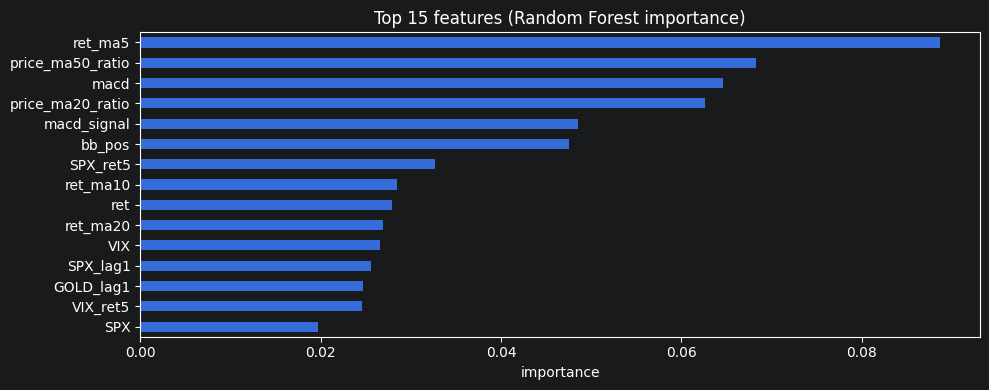


Top 5 features:
ret_ma5             0.088665
price_ma50_ratio    0.068275
macd                0.064642
price_ma20_ratio    0.062663
macd_signal         0.048576
dtype: float64


In [21]:
rf = models["RandomForest"]
fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
top15 = fi.tail(15)

plt.figure(figsize=(10, 4))
top15.plot(kind="barh")
plt.title("Top 15 features (Random Forest importance)")
plt.xlabel("importance")
plt.tight_layout(); plt.show()

print("\nTop 5 features:")
print(top15.tail(5).iloc[::-1])

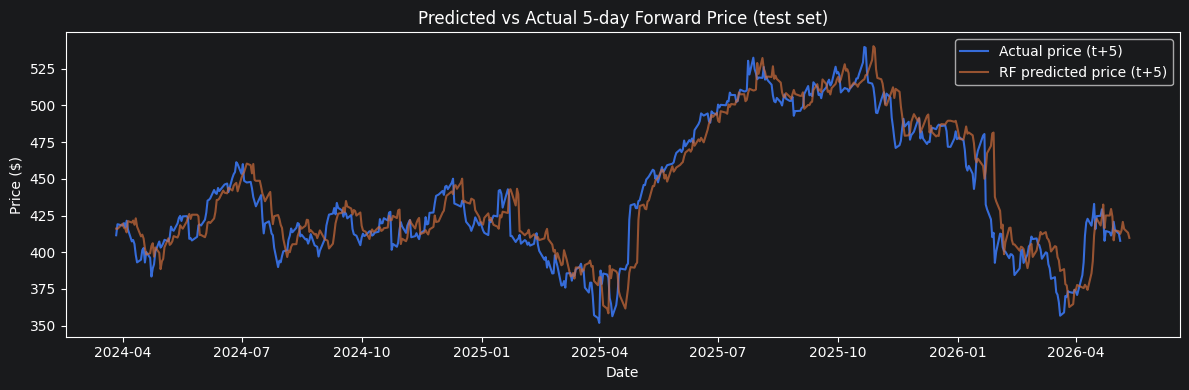

In [22]:
# realized 5-day-forward price = Close shifted -5
test_dates = X_test.index
realized_price  = feat_df.loc[test_dates, "Close"].shift(-5)
predicted_logret = models["RandomForest"].predict(X_test_scaled)
predicted_price  = feat_df.loc[test_dates, "Close"] * np.exp(predicted_logret)

plt.figure(figsize=(12, 4))
plt.plot(test_dates, realized_price,  label="Actual price (t+5)", linewidth=1.5)
plt.plot(test_dates, predicted_price, label="RF predicted price (t+5)", linewidth=1.5, alpha=0.7)
plt.title("Predicted vs Actual 5-day Forward Price (test set)")
plt.xlabel("Date"); plt.ylabel("Price ($)")
plt.legend(); plt.tight_layout(); plt.show()

# 8. Walk-forward Backtest

## run walk-forward

In [23]:
from src.forecast import walk_forward

# use the tuned hyperparams from Phần 6 so walk-forward matches the chosen model
wf_rf_kwargs = dict(**best_params, random_state=SEED, n_jobs=-1)
wf = walk_forward(X, y, initial_train=1000, refit_every=21, horizon=5, rf_kwargs=wf_rf_kwargs)
print("Walk-forward predictions:", len(wf))
print(wf.head())

Walk-forward predictions: 2547
              y_true    y_pred  fit_id
date                                  
2016-03-22  0.017962 -0.002052       0
2016-03-23  0.023078  0.000047       0
2016-03-24  0.024778 -0.000764       0
2016-03-28  0.034692  0.000201       0
2016-03-29 -0.002745 -0.000173       0


                 Strategy_RF (primary)  Strategy_LR (baseline)  SPY B&H (benchmark)
Total return                    3.8327                  4.1733               3.1018
CAGR                            0.1685                  0.1764               0.1497
Sharpe                          0.6984                  0.8494               0.8146
Sortino                         0.8527                  0.9529               0.8773
Calmar                          0.4729                  0.6304               0.5211
Max DD                         -0.3562                 -0.2797              -0.2872
Time underwater                 0.8000                  0.8059               0.6804

RF trades: 50  win rate: 56.9%  |  LR trades: 58  win rate: 58.2%  |  cost: 5 bps/leg


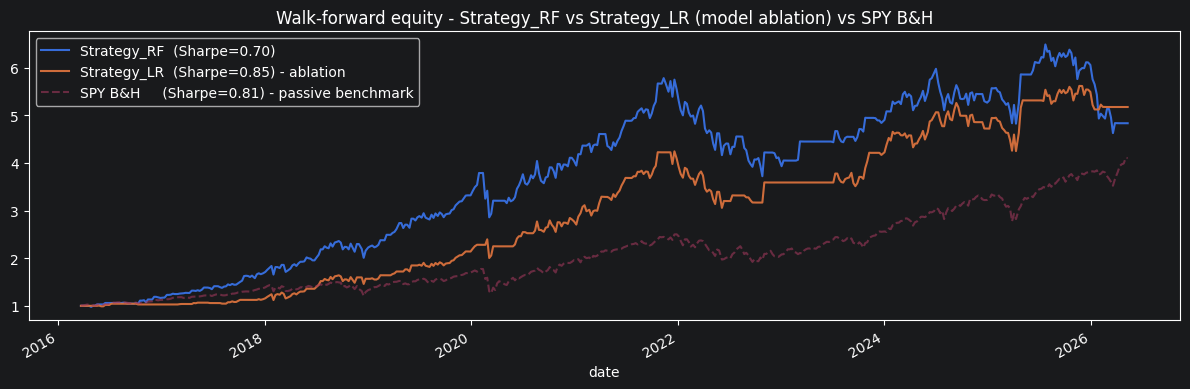

In [24]:
from sklearn.linear_model import LinearRegression
from src.forecast import walk_forward, backtest_strategy, perf_metrics
from src.data     import fetch_stock

# --- 1. Strategy (RF, primary model) ---
result = backtest_strategy(wf, horizon=5, cost_bps=5)

# --- 2. LR baseline (same framework, simpler model) ---
# Re-run walk-forward with LinearRegression - same initial_train/refit/horizon, no hyperparams
wf_lr  = walk_forward(X, y, initial_train=1000, refit_every=21, horizon=5,
                      model_factory=lambda: LinearRegression())
lr_res = backtest_strategy(wf_lr, horizon=5, cost_bps=5)

# --- 3. SPY B&H (passive market index, primary benchmark) ---
spy        = fetch_stock("SPY")
spy_fwd_lr = np.log(spy["Close"].shift(-5) / spy["Close"])
spy_ret    = spy_fwd_lr.reindex(result["bh_ret"].index).dropna()
spy_m      = perf_metrics(spy_ret, horizon=5)

# --- 4. Extended metrics table ---
def row(d): return [d["total_return"], d["cagr"], d["sharpe"], d["sortino"],
                    d["calmar"], d["max_dd"], d["time_underwater"]]
table = pd.DataFrame({
    "Strategy_RF (primary)": row(result),
    "Strategy_LR (baseline)":row(lr_res),
    "SPY B&H (benchmark)":   row(spy_m),
}, index=["Total return", "CAGR", "Sharpe", "Sortino", "Calmar", "Max DD", "Time underwater"])
print(table.round(4).to_string())
print(f"\nRF trades: {result['num_trades']}  win rate: {result['win_rate']*100:.1f}%"
      f"  |  LR trades: {lr_res['num_trades']}  win rate: {lr_res['win_rate']*100:.1f}%"
      f"  |  cost: {result['cost_bps']} bps/leg")

# --- 5. Equity curves: Strategy_RF vs Strategy_LR (ablation) vs SPY B&H (benchmark) ---
fig, ax = plt.subplots(figsize=(12, 4))
result["equity"].plot(ax=ax, label=f"Strategy_RF  (Sharpe={result['sharpe']:.2f})")
lr_res["equity"].plot(ax=ax, label=f"Strategy_LR  (Sharpe={lr_res['sharpe']:.2f}) - ablation")
spy_m["equity"].plot(ax=ax,  label=f"SPY B&H     (Sharpe={spy_m['sharpe']:.2f}) - passive benchmark",
                     linestyle="--", alpha=0.6)
ax.set_title("Walk-forward equity - Strategy_RF vs Strategy_LR (model ablation) vs SPY B&H")
ax.legend(); plt.tight_layout(); plt.show()